<a href="https://colab.research.google.com/github/roberthsu2003/machine_learning/blob/main/%E6%A9%9F%E5%99%A8%E5%AD%B8%E7%BF%92%E5%B8%B8%E4%BD%BF%E7%94%A8%E7%9A%84%E5%9C%96%E8%A1%A8/histogram_kde_%E7%9B%B4%E6%96%B9%E5%9C%96%E8%88%87%E5%AF%86%E5%BA%A6%E5%9C%96.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 直方圖 (Histogram) 與密度圖 (KDE Plot)

在資料分析與特徵工程中，觀察**單一特徵的分佈狀態**是至關重要的第一步。我們常使用以下兩種圖表：
- **直方圖 (Histogram)**：將數據區分成多個區間 (Bins)，統計落入每個區間的樣本數量。適合觀察數據的集中趨勢與分佈範圍。
- **核密度估計圖 (Kernel Density Estimation, KDE)**：對數據分佈進行平滑估計，繪製出連續的機率密度曲線。適合觀察分佈的平滑形狀。

本篇將使用 `Matplotlib` 與 `Seaborn` 來繪製這兩種圖表。

## 1. 環境設定與下載中文字型
在 Google Colab 中繪圖若使用中文標籤常會出現亂碼（豆腐塊），我們需要下載並載入中文字型。

In [2]:
! pip install wget

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=92b169fffd2063a1784e8a5031ea7da50b3f52ef12e2876c1d6ccdf0e8b3f3d8
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


In [3]:
# 下載中文字型
import os
import wget

if not os.path.exists("ChineseFont.ttf"):
    wget.download("https://github.com/roberthsu2003/machine_learning/raw/refs/heads/main/source_data/ChineseFont.ttf")

In [4]:
# 設定 Matplotlib 使用下載的中文字型
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.font_manager import fontManager

fontManager.addfont("ChineseFont.ttf")
mpl.rc('font', family="ChineseFont")
mpl.rcParams['axes.unicode_minus'] = False  # 正常顯示負號

## 2. 建立示範數據
我們使用 `NumPy` 生成一個隨機常態分佈 (Normal Distribution) 的數據集。

In [5]:
import numpy as np
import pandas as pd

# 設定隨機種子以確保結果可重現
np.random.seed(42)

# 生成 1000 個平均數為 50，標準差為 10 的常態分佈樣本
data = np.random.normal(loc=50, scale=10, size=1000)
df = pd.DataFrame(data, columns=["特徵數值"])
df.head()

,特徵數值
0,54.967142
1,48.617357
2,56.476885
3,65.230299
4,47.658466


## 3. 繪製直方圖與密度圖
我們可以使用 `Seaborn` 的 `histplot` 函數同時繪製直方圖與 KDE 平滑曲線。

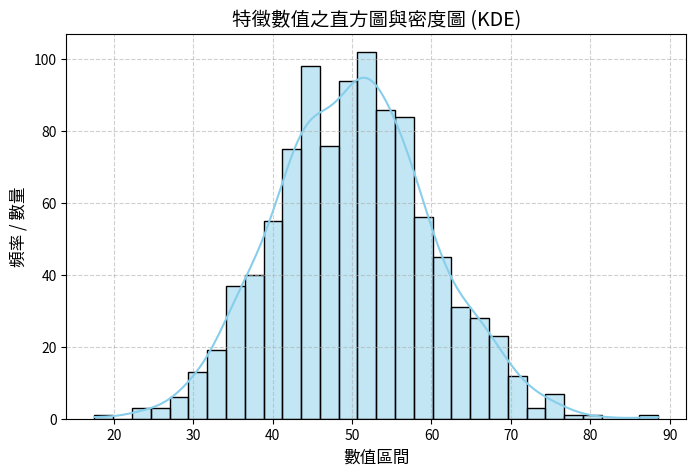

In [6]:
import seaborn as sns

plt.figure(figsize=(8, 5))

# 繪製直方圖並加上 KDE 曲線
sns.histplot(data=df, x="特徵數值", bins=30, kde=True, color="skyblue")

# 設定圖表標題與軸標籤
plt.title("特徵數值之直方圖與密度圖 (KDE)", fontsize=14)
plt.xlabel("數值區間", fontsize=12)
plt.ylabel("頻率 / 數量", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.6)
plt.show()